# SciPy's `solve_ivp`

Solve the semi-batch reactor initial value problem using SciPy's **`solve_ivp`** with the RK45 method.

## 1. Problem statement

The reactor model contains a non-autonomous term (the right-hand side depends on the independent variable $t$ explicitly):

$$\frac{dC_A}{dt}=\frac{\dot{V}}{V_0+\dot{V}t}\left(C_A^{in}-C_A\right)-kC_A, \qquad \frac{dC_B}{dt}=kC_A-\frac{\dot{V}}{V_0+\dot{V}t}C_B.$$

For this example: $C_A^{in}=0.5\ \mathrm{mol/L}$, $\qquad V_0=10\ \mathrm{L}$, $\qquad \dot{V}=0.1\ \mathrm{L/min}$, $\qquad k=0.2\ \mathrm{min}^{-1}$.

Initial conditions: $C_A(0)=1\ \mathrm{mol/L}$, $\qquad C_B(0)=0\ \mathrm{mol/L}$.

We simulate up to $t=30\ \mathrm{min}$.

In [5]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np
import scipy

# Time domain
t_start = 0.0
t_end = 30.0
n = 500
t = np.linspace(t_start, t_end, n)

c0 = np.array([1, 0])  # mol/L

## 2. Define the reaction system

In [6]:
def dC(t: float, c: np.ndarray) -> np.ndarray:
    """ODE system for semi-batch reactor.

    Parameters
    ----------
    t : float
        Time variable
    c : np.ndarray
        Concentration of individual components

    Returns
    -------
    np.ndarray
        Concentration gradient in reactor
    """
    cA, cB = c

    # define constant parameters
    k = 0.2
    Vdot = 0.1
    V_0 = 10
    cA_in = 0.5

    # define the system of ODEs
    dcA = Vdot / (V_0 + Vdot * t) * (cA_in - cA) - k * cA
    dcB = k * cA - Vdot / (V_0 + Vdot * t) * cB

    return np.array([dcA, dcB])

## 3. Solve the IVP with `solve_ivp`

In [7]:
result = scipy.integrate.solve_ivp(fun=dC, t_span=(t[0], t[-1]), y0=c0, t_eval=t, method="RK45")
cA, cB = result.y

## 4. Plot results

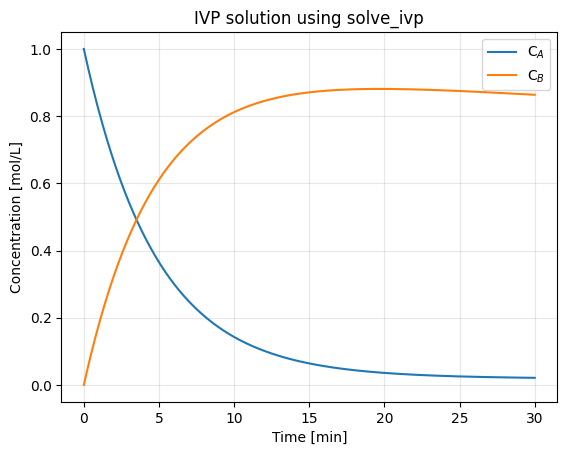

In [8]:
fig, ax = plt.subplots()
ax.plot(t, cA, label="C$_A$")
ax.plot(t, cB, label="C$_B$")
ax.set(xlabel="Time [min]", ylabel="Concentration [mol/L]",
       title="IVP solution using solve_ivp")
ax.legend()
ax.grid(alpha=0.3)
plt.show()